In [1]:
import pandas
data=pandas.read_csv("datasets/family_suitability.csv")
data

,Bedrooms,Area Safety (0-10),Distance to School (km),Distance to Church (km),"Garden (0-No, 1-Yes)",House Age (Years),Family Suitability
0,4,2,4.78,3.29,0,27,Not Good for Family
1,4,4,3.54,3.88,0,21,Not Good for Family
2,1,9,1.54,1.02,1,8,"Yes, Good for Family"
3,5,1,4.22,3.16,0,21,Not Good for Family
4,1,8,1.56,1.33,1,7,Not Good for Family
...,...,...,...,...,...,...,...
95,2,9,0.76,0.53,1,5,"Yes, Good for Family"
96,4,1,3.56,3.35,0,23,Not Good for Family
97,1,9,1.05,1.96,1,4,"Yes, Good for Family"
98,1,9,0.61,0.75,1,1,"Yes, Good for Family"


In [2]:
data.describe()

,Bedrooms,Area Safety (0-10),Distance to School (km),Distance to Church (km),"Garden (0-No, 1-Yes)",House Age (Years)
count,100.000000,100.000000,100.000000,100.000000,100.00,100.000000
mean,2.820000,5.710000,2.500900,2.488100,0.55,12.680000
std,1.671991,3.131124,1.492584,1.456179,0.50,9.448296
min,1.000000,1.000000,0.520000,0.520000,0.00,1.000000
25%,1.000000,3.000000,1.127500,1.120000,0.00,4.000000
50%,2.000000,6.000000,1.900000,1.915000,1.00,9.000000
75%,5.000000,9.000000,3.880000,3.865000,1.00,21.000000
max,5.000000,10.000000,4.990000,4.940000,1.00,29.000000


/tmp/ipykernel_7276/852085773.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Bedrooms",data=data,palette="Reds")


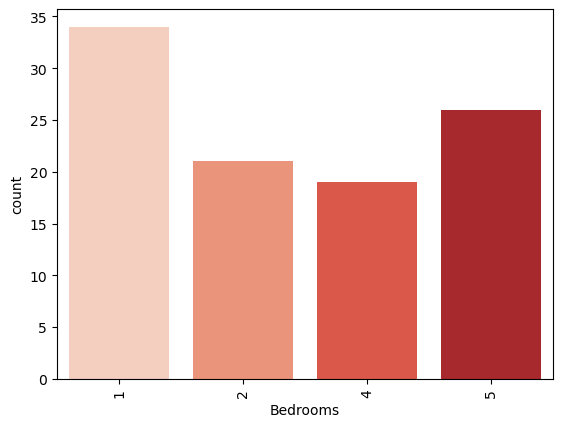

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Bedrooms",data=data,palette="Reds")
plt.xticks(rotation=90)
plt.savefig("family.png")

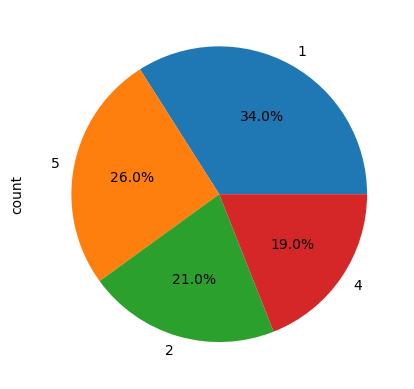

In [4]:
data['Bedrooms'].value_counts().plot.pie(autopct="%1.1f%%")
plt.savefig("piechart2.png")

In [5]:
import pandas
data=pandas.read_csv("datasets/family_suitability.csv")
data

,Bedrooms,Area Safety (0-10),Distance to School (km),Distance to Church (km),"Garden (0-No, 1-Yes)",House Age (Years),Family Suitability
0,4,2,4.78,3.29,0,27,Not Good for Family
1,4,4,3.54,3.88,0,21,Not Good for Family
2,1,9,1.54,1.02,1,8,"Yes, Good for Family"
3,5,1,4.22,3.16,0,21,Not Good for Family
4,1,8,1.56,1.33,1,7,Not Good for Family
...,...,...,...,...,...,...,...
95,2,9,0.76,0.53,1,5,"Yes, Good for Family"
96,4,1,3.56,3.35,0,23,Not Good for Family
97,1,9,1.05,1.96,1,4,"Yes, Good for Family"
98,1,9,0.61,0.75,1,1,"Yes, Good for Family"


In [6]:
array=data.values
X=array[:,0:6]
# X
Y=array[:,6]
# Y

In [7]:
from sklearn import model_selection
X_train,X_test,Y_train,Y_test=model_selection.train_test_split(X,Y,test_size=0.30,random_state=42)

In [8]:
Y_train = Y_train.ravel()

In [9]:
from sklearn.svm import SVC 
model=SVC()
model.fit(X_train,Y_train)

SVC()

In [10]:
predictions=model.predict(X_test)
print("The predictions are",predictions)
print("The expected values are",Y_test)

The predictions are ['Yes, Good for Family' 'Not Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Yes, Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Not Good for Family' 'Not Good for Family'
 'Not Good for Family' 'Yes, Good for Family' 'Not Good for Family'
 'Yes, Good for Family' 'Not Good for Family' 'Yes, Good for Family'
 'Yes, Good for Family' 'Yes, Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Not Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Not Good for Family' 'Yes, Good for Family'
 'Yes, Good for Family' 'Not Good for Family' 'Not Good for Family'
 'Not Good for Family' 'Yes, Good for Family' 'Not Good for Family']
The expected values are ['Yes, Good for Family' 'Not Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Yes, Good for Family' 'Yes, Good for Family'
 'Not Good for Family' 'Not Good for Family' 'Not Good for Family'
 'Not Good for Family' 'Yes, Good for Family' 'Not Good for Family

In [11]:
from sklearn.metrics import accuracy_score
print("The accuracy is",accuracy_score(Y_test,predictions))

The accuracy is 0.9333333333333333


In [12]:
# Imports Classification Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC

# Create an Empty List and append all models, Give the Models an alias Name
# i.e we called KNeighborsClassifier() alias KNC etc
models = []
models.append(('D Trees', DecisionTreeClassifier()))
models.append(('Gaussian', GaussianNB()))
models.append(('KNC', KNeighborsClassifier()))
models.append(('Random Forest', RandomForestClassifier()))
models.append(('Gradient Boosting', GradientBoostingClassifier()))
models.append(('Linear Disc', LinearDiscriminantAnalysis()))
models.append(('Support Machines', SVC(gamma = 'auto')))

# Import Cross Validation and KFOLD
from sklearn.model_selection import cross_val_score, KFold
# Create a for loop so that each model is tested in turn
for name, model in models:
            # Here we do a 10 split K-FOLD
            kfold = KFold(n_splits = 10, random_state=42, shuffle=True)

            # We get the results for each Fold
            cv_results = cross_val_score(model, X_train, Y_train, cv = kfold,
            scoring='accuracy')

            # Get the average of all Folds
            print(name, ' Results:= ', cv_results.mean())

D Trees  Results:=  0.9
Gaussian  Results:=  0.9571428571428571
KNC  Results:=  0.9571428571428571
Random Forest  Results:=  0.9571428571428571
Gradient Boosting  Results:=  0.9142857142857144
Linear Disc  Results:=  0.9571428571428571
Support Machines  Results:=  0.9571428571428571
